# 02a — Exploring the CoDA Dark Web Corpus

Before fine-tuning anything on CoDA, **read the data**. This notebook answers three questions:

1. **What's in CoDA?** Class balance, languages, length distributions, boilerplate.
2. **How does dark web text differ from surface web text?** Side-by-side against Wikipedia — vocabulary, OOV rate, lexical diversity.
3. **What CTI-relevant signals are in there?** Crypto wallets, PGP blocks, .onion URLs, CVEs, emails — without any model, just regex.

The point is *insight*, not metrics. By the end you should have opinions about what makes this data hard, and why a dark-web-pretrained model might help.

## Prerequisites

```bash
pip install -U pandas matplotlib seaborn wikipedia transformers datasets
```

CoDA must already be extracted at `data/coda/coda_dataset/` — see the download cell in nb 03 if not.

## 1 — Corpus shape

Parse filenames (format: `<id>-<category>-<lang>-<hash>.txt`), load all 10,000 docs, look at class and language distributions.

In [1]:
import re, json, random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 5)

CODA_DIR = Path('data/coda/coda_dataset')
assert CODA_DIR.exists(), 'CoDA not found. Run the download cell in nb 03 first.'

rows = []
for f in CODA_DIR.glob('*.txt'):
    parts = f.stem.split('-')
    if len(parts) < 4:
        continue
    rows.append({
        'id': parts[0],
        'category': parts[1],
        'lang': parts[2],
        'path': f,
    })
coda = pd.DataFrame(rows)
print(f'Total docs: {len(coda)}')
print(f'Categories: {coda["category"].nunique()}')
print(f'Languages:  {coda["lang"].nunique()}')

Total docs: 10000
Categories: 10
Languages:  51


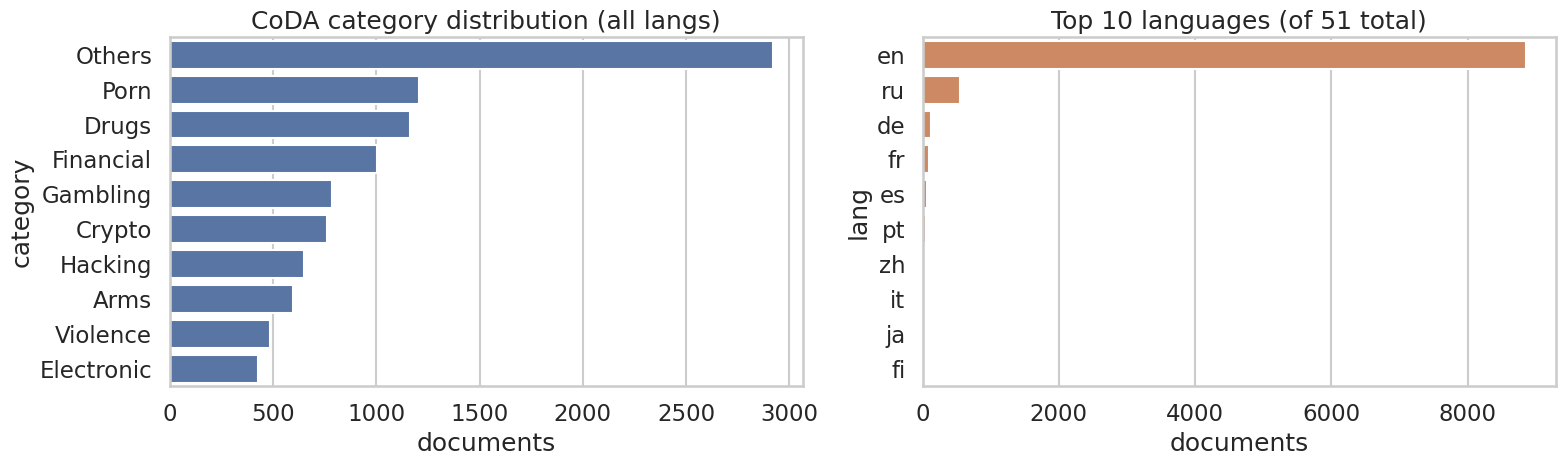

English share: 88.5%
Top 5 langs cover: 96.9%


In [2]:
# --- Class distribution ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cat_counts = coda['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0], color='#4c72b0')
axes[0].set_title('CoDA category distribution (all langs)')
axes[0].set_xlabel('documents')

lang_counts = coda['lang'].value_counts().head(10)
sns.barplot(x=lang_counts.values, y=lang_counts.index, ax=axes[1], color='#dd8452')
axes[1].set_title(f'Top 10 languages (of {coda["lang"].nunique()} total)')
axes[1].set_xlabel('documents')
plt.tight_layout(); plt.show()

print(f'English share: {(coda["lang"]=="en").mean()*100:.1f}%')
print(f'Top 5 langs cover: {lang_counts.head(5).sum()/len(coda)*100:.1f}%')

Loading text for 8855 English docs...


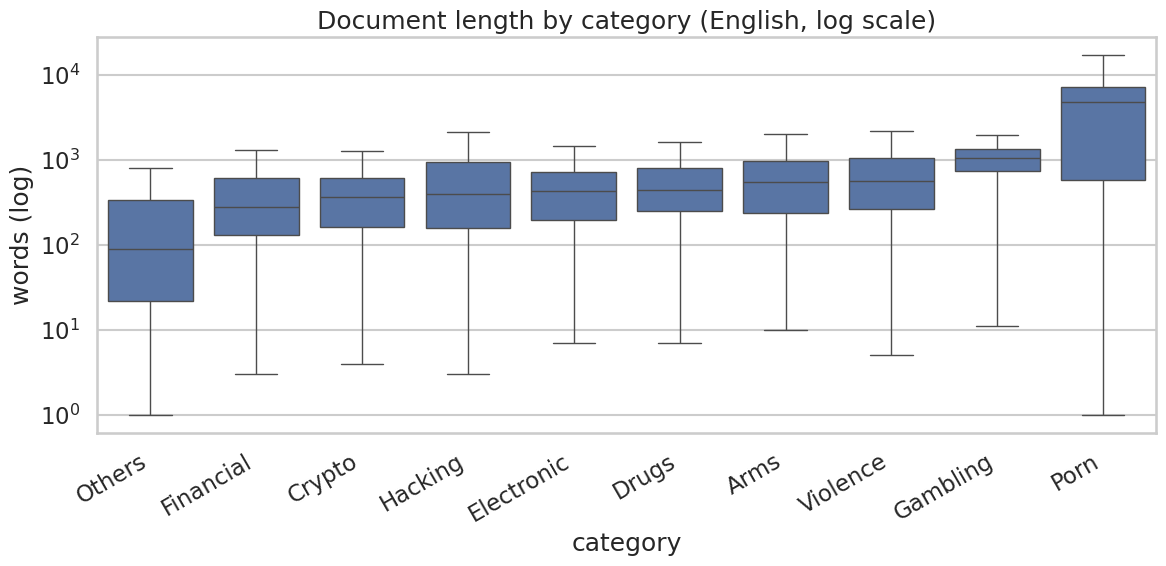

Median length per category:
category
Porn          4878
Gambling      1050
Violence       566
Arms           553
Drugs          443
Electronic     428
Hacking        400
Crypto         365
Financial      281
Others          90


In [3]:
# --- Load text for all English docs, compute word counts -------------
coda_en = coda[coda['lang']=='en'].copy()
print(f'Loading text for {len(coda_en)} English docs...')
coda_en['text'] = coda_en['path'].apply(lambda p: p.read_text(errors='ignore'))
coda_en['word_count'] = coda_en['text'].str.split().str.len()

# --- Length distribution per category --------------------------------
plt.figure(figsize=(12, 6))
order = coda_en.groupby('category')['word_count'].median().sort_values().index
sns.boxplot(data=coda_en, x='category', y='word_count', order=order, showfliers=False)
plt.yscale('log')
plt.xticks(rotation=30, ha='right')
plt.title('Document length by category (English, log scale)')
plt.ylabel('words (log)')
plt.tight_layout(); plt.show()

print('Median length per category:')
print(coda_en.groupby('category')['word_count'].median().sort_values(ascending=False).astype(int).to_string())

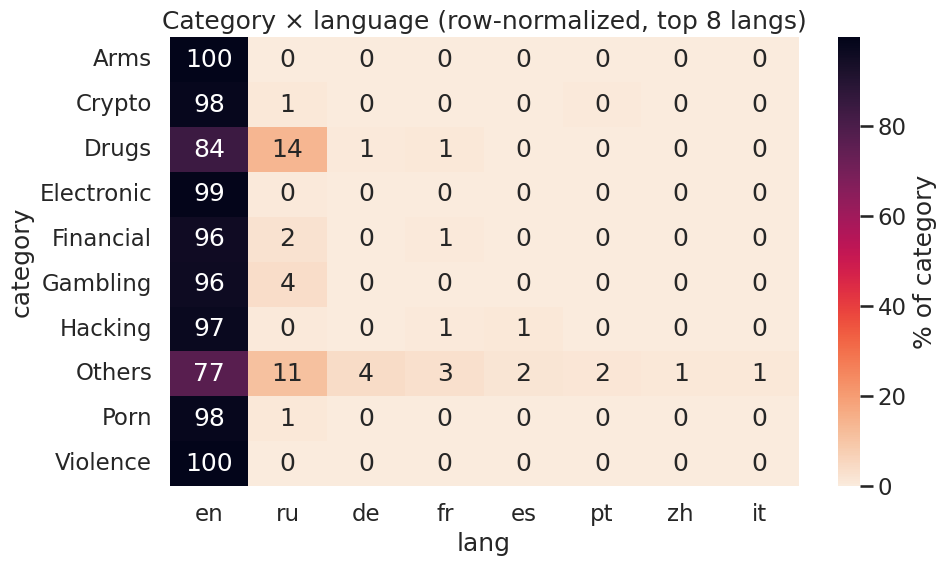

In [4]:
# --- Language × category heatmap (tells you who sells what in what language)
xtab = pd.crosstab(coda['category'], coda['lang'])
top_langs = xtab.sum().sort_values(ascending=False).head(8).index
xtab = xtab[top_langs]
# Row-normalize: % of each category by language
xtab_pct = xtab.div(xtab.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(xtab_pct, annot=True, fmt='.0f', cmap='rocket_r', cbar_kws={'label': '% of category'})
plt.title('Category × language (row-normalized, top 8 langs)')
plt.tight_layout(); plt.show()

**What to notice.** CoDA is heavily English but the language mix isn't uniform across categories — some categories lean more heavily non-English than others. `Others` is a garbage-bin class that will drag any classifier down. Document length varies wildly between categories — `Hacking` and `Financial` tend to be longer (forum/how-to style) while `Electronic` is shorter (listing style).

## 2 — What does this text actually look like?

Plots are abstractions. Read the raw bytes.

In [7]:
random.seed(7)
for cat in ['Drugs', 'Hacking', 'Financial', 'Arms']:
    sub = coda_en[(coda_en['category']==cat) & (coda_en['word_count'].between(150, 1500))]
    if len(sub) == 0:
        continue
    s = sub.sample(1, random_state=random.randint(0, 10000)).iloc[0]
    print(f'===== {cat} (id={s["id"]}, {s["word_count"]} words) =====')
    print(s['text'][:1000])
    print()

===== Drugs (id=5681, 202 words) =====

 
 white onion 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
                    this is the link of the white onion shop write it and check it is ok 
 ID_ONION_URL 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 buying in this shop is easy, you only have to enter a username, a password and the captcha challenge to enter. this is not a registration, it is only for this shopping session. 
 
 
 remember your username and password during the session because they will be required when making inquiries or purchases. 
 
 
 you can use different user and password each time you enter this shop. or not, as you like. 
 
 
 this web shop doesn't store any data from the customers in the server for security reasons. nothing is nothing. 
 
 
 only session data is collected in memory along the shopping session for working properly, but will be deleted after closing the browser and when you press the logout button. 
 
 
 when an order is finished, an email 

**Impressions from just reading.** Listings are templated, marketing-ish, full of product specs and shipping promises. Forums are stream-of-consciousness with heavy slang. Many pages start with navigation/header text that's identical across the site. A lot of this is *noise* from the classifier's point of view — unless the noise itself is the signal (PGP blocks, .onion mirror lists, etc).

## 3 — Boilerplate and structural noise

How much of an average onion page is **PGP blocks, .onion mirror lists, long hex strings, and other structural junk**? This is noise for classification but signal for "what kind of service is this".

In [8]:
PGP_RE = re.compile(r'-----BEGIN PGP[\s\S]*?-----END PGP[^-]*-----')
ONION_RE = re.compile(r'\b[a-z2-7]{16,56}\.onion\b')
LONG_HEX_RE = re.compile(r'\b[0-9a-f]{32,}\b')

def boilerplate_stats(text):
    total = max(len(text), 1)
    pgp_chars = sum(len(m) for m in PGP_RE.findall(text))
    onion_hits = len(ONION_RE.findall(text))
    hex_hits = len(LONG_HEX_RE.findall(text))
    return {
        'pgp_pct': pgp_chars / total * 100,
        'onion_count': onion_hits,
        'longhex_count': hex_hits,
    }

stats = coda_en['text'].apply(boilerplate_stats).apply(pd.Series)
stats['category'] = coda_en['category'].values

print(f'Pages containing a PGP block:     {(stats["pgp_pct"] > 0).mean()*100:.1f}%')
print(f'Pages with at least one .onion:   {(stats["onion_count"] > 0).mean()*100:.1f}%')
print(f'Pages with long hex strings:      {(stats["longhex_count"] > 0).mean()*100:.1f}%')

print('\nAverage .onion mentions per page, by category:')
print(stats.groupby('category')['onion_count'].mean().sort_values(ascending=False).round(2).to_string())

print('\n% of page that is PGP, by category:')
print(stats.groupby('category')['pgp_pct'].mean().sort_values(ascending=False).round(2).to_string())

Pages containing a PGP block:     0.0%
Pages with at least one .onion:   1.3%
Pages with long hex strings:      0.3%

Average .onion mentions per page, by category:
category
Crypto        0.48
Financial     0.01
Others        0.00
Electronic    0.00
Hacking       0.00
Drugs         0.00
Porn          0.00
Arms          0.00
Gambling      0.00
Violence      0.00

% of page that is PGP, by category:
category
Arms          0.0
Crypto        0.0
Drugs         0.0
Electronic    0.0
Financial     0.0
Gambling      0.0
Hacking       0.0
Others        0.0
Porn          0.0
Violence      0.0


**What to notice.** Pages that are mostly PGP block are useless for semantic classification — the model sees 600 tokens of base64. Categories that lean heavily on PGP (markets, forums where verification matters) are systematically *harder to classify* for a language model, because a lot of the input is literally non-language. This is a tokenization / preprocessing problem that doesn't exist on the surface web.

## 4 — Dark vs surface: vocabulary divergence

Pull a reference Wikipedia sample, then compare what words are over-represented in dark web vs. surface web. This is the clearest visual answer to "is this language different?"

In [9]:
import wikipedia
WIKI_CACHE = Path('processed/wiki_sample.txt')
WIKI_CACHE.parent.mkdir(exist_ok=True)

if not WIKI_CACHE.exists():
    print('Pulling 400 random Wikipedia articles (one-time, ~2 min)...')
    wikipedia.set_lang('en')
    chunks = []
    tried = 0
    while len(chunks) < 400 and tried < 600:
        tried += 1
        try:
            title = wikipedia.random(pages=1)
            page = wikipedia.page(title, auto_suggest=False)
            chunks.append(page.content)
        except Exception:
            continue
    WIKI_CACHE.write_text('\n\n=====\n\n'.join(chunks))
    print(f'Saved {len(chunks)} articles')

wiki_text = WIKI_CACHE.read_text()
print(f'Wiki sample: {len(wiki_text.split()):,} words')

# Sample a matched word count from CoDA EN for fair comparison
coda_text_all = ' '.join(coda_en['text'].tolist())
print(f'CoDA EN:    {len(coda_text_all.split()):,} words')

Pulling 400 random Wikipedia articles (one-time, ~2 min)...


/home/saqib/venv/lib/python3.12/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /home/saqib/venv/lib/python3.12/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Saved 400 articles
Wiki sample: 213,319 words
CoDA EN:    10,812,435 words


In [10]:
# --- Log-odds ratio with informative Dirichlet prior (Monroe et al. 2008)
# Standard technique for "what words distinguish corpus A from corpus B"
WORD = re.compile(r"[a-zA-Z][a-zA-Z'-]{2,}")
STOP = set('the and for are but not you all any can her his its our out that this with from have has had was were will'.split())

def word_counts(text):
    c = Counter(w.lower() for w in WORD.findall(text))
    for s in STOP: c.pop(s, None)
    return c

c_coda = word_counts(coda_text_all)
c_wiki = word_counts(wiki_text)

# Keep vocabulary seen enough times to be meaningful
vocab = {w for w in (c_coda.keys() | c_wiki.keys()) if c_coda[w] + c_wiki[w] >= 30}
n_coda, n_wiki = sum(c_coda.values()), sum(c_wiki.values())
alpha = 0.01  # Dirichlet prior weight
a0 = alpha * len(vocab)

records = []
for w in vocab:
    y_coda = c_coda[w] + alpha
    y_wiki = c_wiki[w] + alpha
    logodds = (np.log(y_coda / (n_coda + a0 - y_coda))
               - np.log(y_wiki / (n_wiki + a0 - y_wiki)))
    variance = 1/y_coda + 1/y_wiki
    z = logodds / np.sqrt(variance)
    records.append((w, z, c_coda[w], c_wiki[w]))
logodds_df = pd.DataFrame(records, columns=['word', 'z', 'n_coda', 'n_wiki']).sort_values('z')

print('Top 30 DARK-WEB-distinctive words (high z = over-represented in CoDA):')
print(logodds_df.tail(30).iloc[::-1].to_string(index=False))
print('\nTop 20 WIKIPEDIA-distinctive words (for calibration):')
print(logodds_df.head(20).to_string(index=False))

Top 30 DARK-WEB-distinctive words (high z = over-represented in CoDA):
   word         z  n_coda  n_wiki
 number 38.044836  310318      85
   free 25.055945   92389      60
  video 20.898242   80254      31
   time 20.757512   58916     277
general 19.970513   45143      89
    sex 19.948252   58828      38
  money 18.092853   69416      20
   your 15.258778   41945      17
   girl 14.742806   29729      24
  young 14.685974   25063      39
 online 14.407276   35787      16
  child 13.915493   26128      22
   just 12.853656   18985      53
   what 12.746505   19825      72
 little 12.714729   18826      29
    how 12.678630   18203      42
  girls 12.639095   18377      31
    get 12.434512   18403      25
 videos 11.984523   27009      10
    boy 11.836216   19490      15
   like 11.734709   18220      80
    url 11.704430   24729      10
   said 11.595737   18019      81
    she 11.244315   44541     420
    buy 11.147974   18332      12
   down 10.711911   13753      47
    now 10.

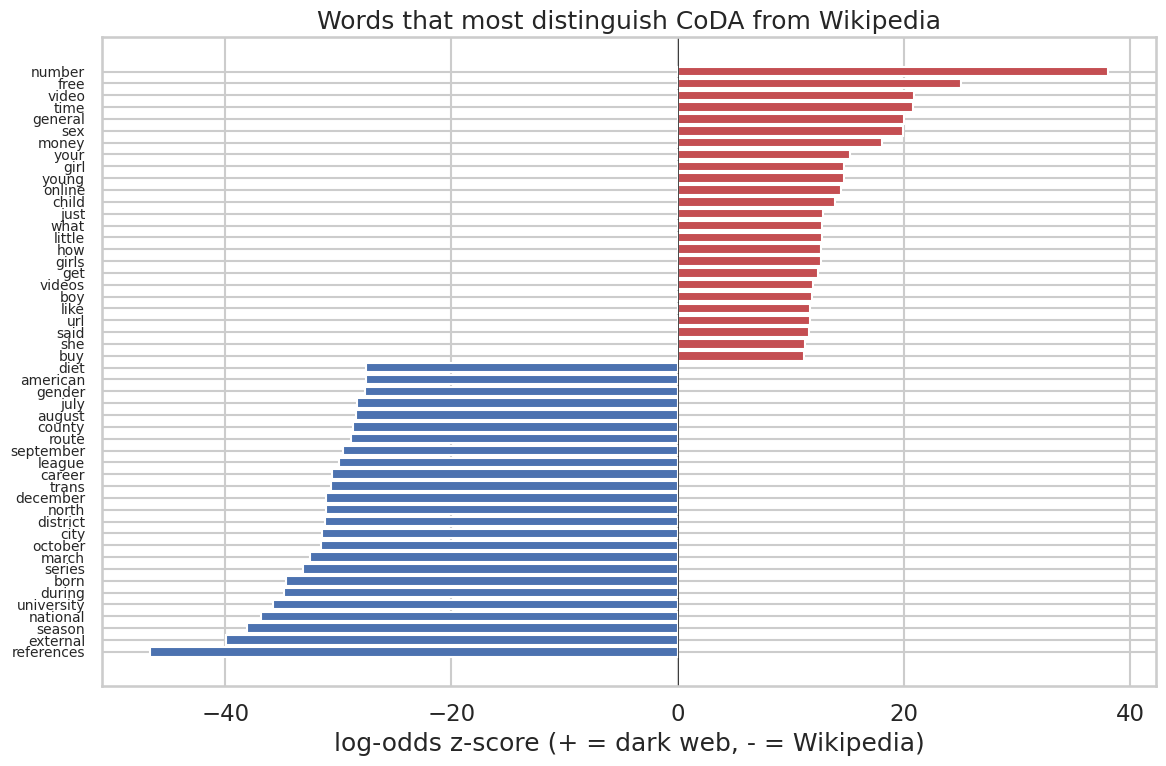

In [11]:
# --- Visualize the divergence
fig, ax = plt.subplots(figsize=(12, 8))
top = logodds_df.tail(25)
bot = logodds_df.head(25)
comb = pd.concat([bot, top])
colors = ['#c44e52' if z > 0 else '#4c72b0' for z in comb['z']]
ax.barh(range(len(comb)), comb['z'], color=colors)
ax.set_yticks(range(len(comb)))
ax.set_yticklabels(comb['word'], fontsize=10)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('log-odds z-score (+ = dark web, - = Wikipedia)')
ax.set_title('Words that most distinguish CoDA from Wikipedia')
plt.tight_layout(); plt.show()

**What to notice.** The dark-web side is dominated by **commerce/service vocabulary** (shipping, bitcoin, escrow, stealth, pgp, order, vendor) and **underground product terms** (cocaine, cannabis, cvv, etc.). Wikipedia's distinctive words are biographical/academic. Two corpora, same language, vastly different *registers*. A model pretrained on Wikipedia sees a lot of these dark-web tokens as rare — that's the motivation for DarkBERT.

## 5 — Out-of-vocabulary rate against a standard BERT tokenizer

Concrete, operational version of the vocabulary question: when you tokenize CoDA with a bert-base-uncased tokenizer (trained on Wikipedia + BookCorpus), how often does it fall back to `##subword` splits? Higher split rate = more of the text is in BERT's OOV tail.

Token indices sequence length is longer than the specified maximum sequence length for this model (1156 > 512). Running this sequence through the model will result in indexing errors


Subword ratio (CoDA):      0.120 mean, 0.106 median
Subword ratio (Wikipedia): 0.112 mean, 0.097 median
Relative: CoDA is 1.07× more fragmented


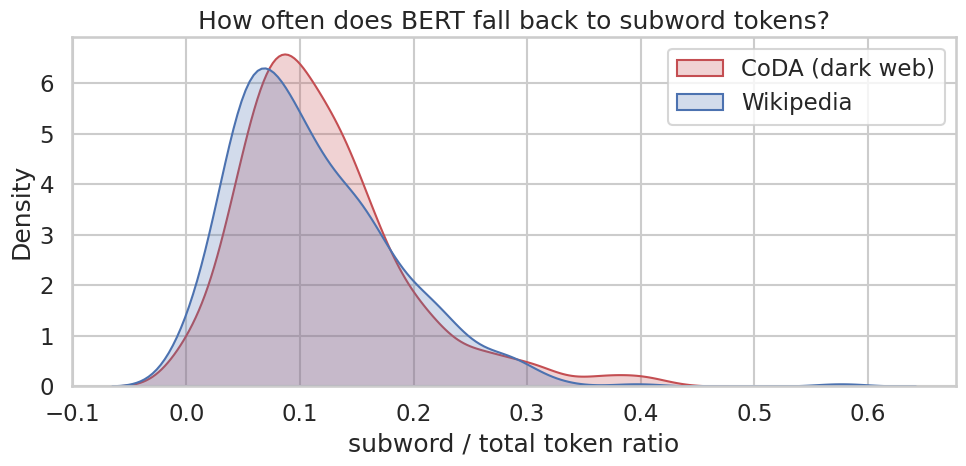

In [12]:
from transformers import AutoTokenizer
bert = AutoTokenizer.from_pretrained('bert-base-uncased')

def subword_ratio(text, n_sample_words=2000):
    # Ratio of subword tokens (##xxx) to whole-word tokens. Higher = more OOV.
    words = text.split()[:n_sample_words]
    if not words: return 0.0
    toks = bert.tokenize(' '.join(words))
    if not toks: return 0.0
    return sum(1 for t in toks if t.startswith('##')) / len(toks)

# Sample for speed
coda_sample = coda_en.sample(min(500, len(coda_en)), random_state=1)
coda_subword = coda_sample['text'].apply(subword_ratio)

wiki_chunks = wiki_text.split('\n\n=====\n\n')
wiki_subword = pd.Series([subword_ratio(c) for c in wiki_chunks[:500]])

print(f'Subword ratio (CoDA):      {coda_subword.mean():.3f} mean, {coda_subword.median():.3f} median')
print(f'Subword ratio (Wikipedia): {wiki_subword.mean():.3f} mean, {wiki_subword.median():.3f} median')
print(f'Relative: CoDA is {coda_subword.mean()/wiki_subword.mean():.2f}× more fragmented')

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(coda_subword, label='CoDA (dark web)', fill=True, ax=ax, color='#c44e52')
sns.kdeplot(wiki_subword, label='Wikipedia', fill=True, ax=ax, color='#4c72b0')
ax.set_xlabel('subword / total token ratio')
ax.set_title('How often does BERT fall back to subword tokens?')
ax.legend()
plt.tight_layout(); plt.show()

**What to notice.** Higher subword rate means BERT is burning more tokens on the same amount of text, *and* the model has weaker representations for those subword-split terms. This is the quantitative case for domain pretraining: a tokenizer that knows about dark-web jargon will represent the same content in fewer, more semantic tokens.

## 6 — CTI-relevant entities, with zero models

Before any fancy NER, see what regex alone finds: crypto wallets, .onion URLs, PGP blocks, emails, CVEs, credential-dump keywords. These are the raw CTI signals in the data.

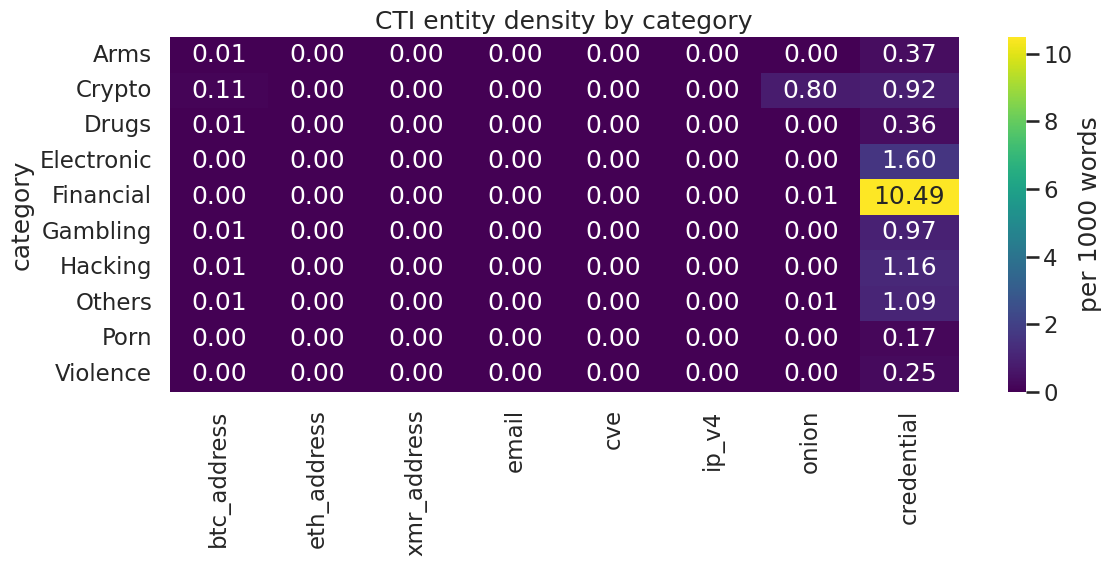

Total entity counts across CoDA EN:
credential     10849
onion            375
btc_address       97
email              2
xmr_address        0
eth_address        0
ip_v4              0
cve                0


In [13]:
ENTITY_RE = {
    'btc_address':  re.compile(r'\b(?:bc1[a-z0-9]{25,60}|[13][a-km-zA-HJ-NP-Z1-9]{25,34})\b'),
    'eth_address':  re.compile(r'\b0x[a-fA-F0-9]{40}\b'),
    'xmr_address':  re.compile(r'\b4[0-9AB][1-9A-HJ-NP-Za-km-z]{93}\b'),
    'email':        re.compile(r'\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b'),
    'cve':          re.compile(r'\bCVE-\d{4}-\d{4,7}\b', re.IGNORECASE),
    'ip_v4':        re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b'),
    'onion':        re.compile(r'\b[a-z2-7]{16,56}\.onion\b'),
    'credential':   re.compile(r'\b(?:fullz|dumps?|cvv2?|rdp|ssh|vpn\s+accounts?|logs?|bins?)\b', re.IGNORECASE),
}

def count_entities(text):
    return {k: len(v.findall(text)) for k, v in ENTITY_RE.items()}

ent = coda_en['text'].apply(count_entities).apply(pd.Series)
ent['category'] = coda_en['category'].values

# --- Mentions per 1000 words, per category ---------------------------
per_cat = ent.groupby('category').sum(numeric_only=True)
words_per_cat = coda_en.groupby('category')['word_count'].sum()
rate = per_cat.div(words_per_cat, axis=0) * 1000
rate = rate.drop(columns=['category'], errors='ignore')

plt.figure(figsize=(12, 6))
sns.heatmap(rate, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'per 1000 words'})
plt.title('CTI entity density by category')
plt.tight_layout(); plt.show()

print('Total entity counts across CoDA EN:')
print(ent.drop(columns=['category']).sum().sort_values(ascending=False).to_string())

**What to notice.** The heatmap is a CTI fingerprint. `Financial` lights up for BTC addresses and credential keywords. `Hacking` has elevated CVE mentions. `.onion` URLs scatter everywhere (everyone lists their mirrors). **This suggests a simple CTI pipeline:** just regex extraction + the category label already gives you the 80% useful version of dark-web intel. NER for the long tail.

## 7 — Dark-web jargon by category

A curated list of ~25 underground-specific terms. How often do they appear, and where? This is the concrete view of "the language is different" — not abstract divergence scores, just specific words.

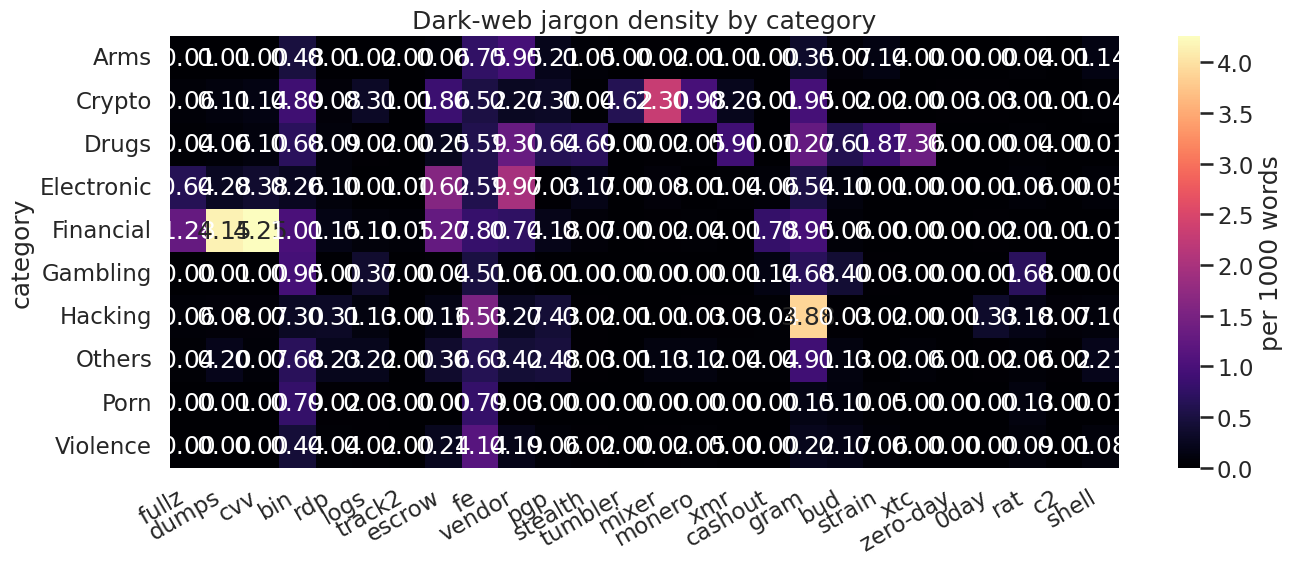

In [14]:
JARGON = [
    # credential/card fraud
    'fullz', 'dumps', 'cvv', 'bin', 'rdp', 'logs', 'track2',
    # markets & trust
    'escrow', 'fe ', 'vendor', 'pgp', 'stealth',
    # payments & laundering
    'tumbler', 'mixer', 'monero', 'xmr', 'cashout',
    # drugs
    'gram', 'bud', 'strain', 'xtc',
    # hacking
    'zero-day', '0day', 'rat ', 'c2 ', 'shell',
]

def count_jargon(text, terms):
    lo = text.lower()
    return {t.strip(): lo.count(t) for t in terms}

jar = coda_en['text'].apply(lambda t: count_jargon(t, JARGON)).apply(pd.Series)
jar['category'] = coda_en['category'].values
jar_rate = jar.groupby('category').sum(numeric_only=True).div(words_per_cat, axis=0) * 1000
jar_rate = jar_rate.drop(columns=['category'], errors='ignore')

plt.figure(figsize=(14, 6))
sns.heatmap(jar_rate, annot=True, fmt='.2f', cmap='magma', cbar_kws={'label': 'per 1000 words'})
plt.title('Dark-web jargon density by category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 8 — Insights, summarized

What a classifier builder should walk away with:

1. **Class imbalance is real.** `Others` is 29% and is a garbage class — drop it for fine-tuning. `Electronic` and `Violence` are the smallest real classes and will be the weak links in macro F1.
2. **Language: English-only is a defensible simplification** — 88% of docs, and the other 49 languages are too thinly spread to learn from. A cross-lingual story needs XLM-R + language-grouped data.
3. **Documents are long but highly redundant.** Most of the classification signal lives in the first ~512 tokens; the rest is often navigation, mirror lists, and templated boilerplate. DarkBERT's 512-token limit is less of a handicap than it looks.
4. **PGP blocks, long hex strings, and .onion lists are a measurable fraction of the input.** This is *tokenizer-hostile* content. A model pretrained on dark web data has vocabulary for it; generic BERT burns tokens on subword splits.
5. **Vocabulary divergence is large and concentrated.** The distinctive dark-web words are commerce + underground-product vocabulary that a Wikipedia-pretrained model has weak representations for. Concrete motivation for DarkBERT / continue-pretraining.
6. **Regex alone is already powerful.** Wallet addresses, CVEs, emails, credential keywords are all extractable without a model, and their *category-conditional density* is itself a useful feature. A small regex layer + the classifier gives you most of the value.
7. **`Financial` and `Hacking` are the most CTI-valuable categories** — highest density of wallet addresses, CVEs, and credential-fraud terminology. Prioritize these in any downstream pipeline.